Imports & Loading

In [1]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Ensure we can import from the src directory
import sys
sys.path.append('..')

# Import our modular logic
from src.processor import DataProcessor
from src.models import EnsembleWrapper
from src.conformal import get_residuals, apply_enbpi, rolling_agaci
from src.visualization import plot_forecast_vs_actual, plot_prediction_intervals, calculate_metrics

# Load Project Configuration
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Set plotting style
plt.style.use('ggplot')
%matplotlib inline

I0000 00:00:1774978869.879684       8 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774978869.880308       8 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774978869.925602       8 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1774978871.614046       8 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774978871.614389       8 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Exploratory Data Analysis (EDA)

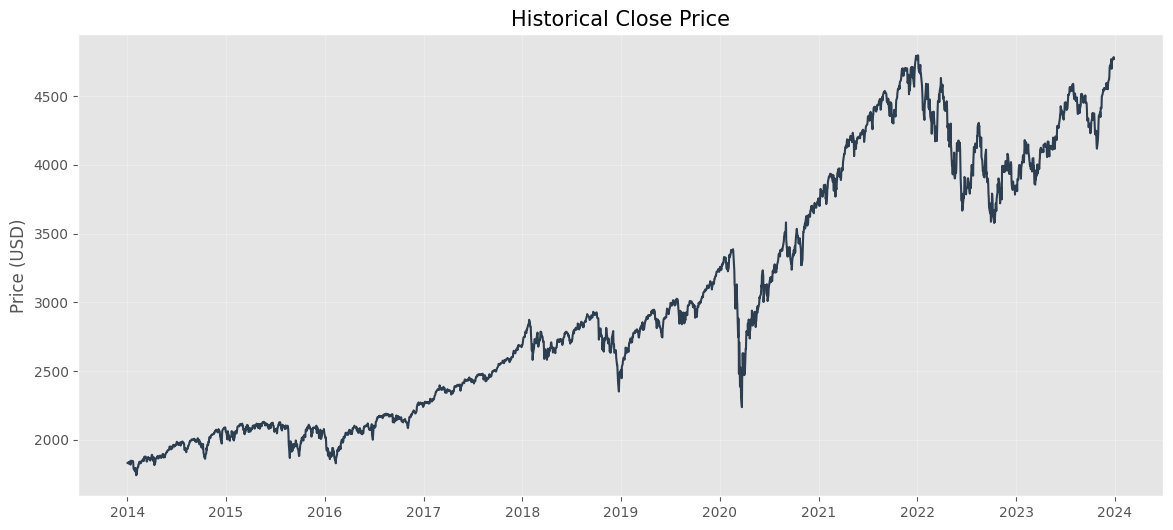

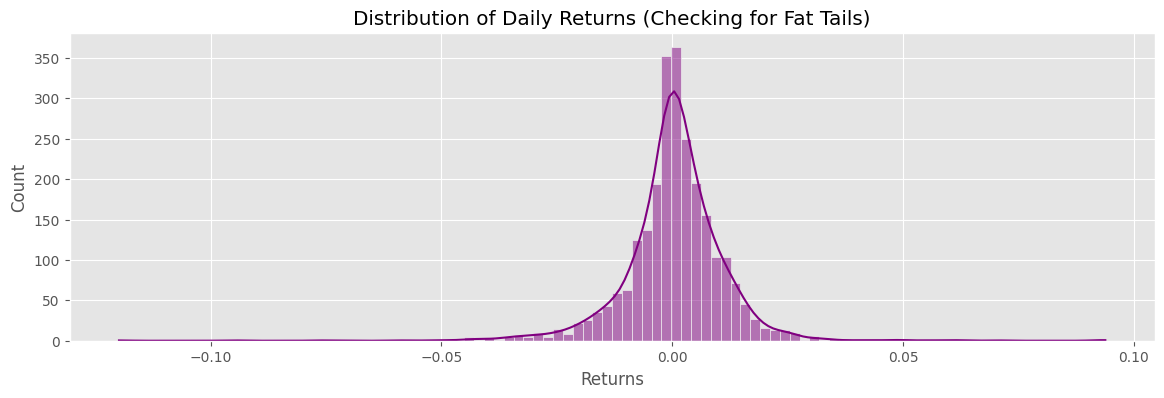

Dataset Statistics:
count    2516.000000
mean     3005.883140
std       901.337964
min      1741.890015
25%      2124.267517
50%      2798.160034
75%      3907.079956
max      4796.560059
Name: Close, dtype: float64


In [2]:
# 1. Load Data
df = pd.read_csv(f"../{config['data']['file_path']}")
col = config['data']['target_column']

# Ensure numeric (fixes '^GSPC' / string issues)
df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop invalid values
df = df.dropna(subset=[col])

# Convert and set datetime index
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

# 2. Visualizing the Target
plt.figure(figsize=(14, 6))
plt.plot(df[config['data']['target_column']], color='#2c3e50')
plt.title(f"Historical {config['data']['target_column']} Price", fontsize=15)
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Volatility Analysis (Returns)
df['Returns'] = df[config['data']['target_column']].pct_change()
plt.figure(figsize=(14, 4))
sns.histplot(x=df['Returns'].dropna(), bins=100, kde=True, color='purple')
plt.title("Distribution of Daily Returns (Checking for Fat Tails)")
plt.show()

print(f"Dataset Statistics:\n{df[config['data']['target_column']].describe()}")

Data Preprocessing

In [3]:
# Initialize Processor
dp = DataProcessor(window=config['data']['window_size'])

# Scale and Sequence
scaled_data = dp.load_and_scale(f"../{config['data']['file_path']}")
X, y = dp.create_sequences(scaled_data)

# Train/Calibration/Test Split
(X_train, y_train), (X_cal, y_cal), (X_test, y_test) = dp.split_data(
    X, y, 
    train_p=config['data']['train_split'], 
    cal_p=config['data']['cal_split']
)

print(f"Data Shapes:\nTrain: {X_train.shape} | Cal: {X_cal.shape} | Test: {X_test.shape}")

Data Shapes:
Train: (1491, 30, 1) | Cal: (497, 30, 1) | Test: (498, 30, 1)


Model Training (Ensemble)

In [4]:
print("--- Training LSTM Ensemble ---")
lstm_ens = EnsembleWrapper('LSTM', B=config['model']['ensemble_size'])
lstm_ens.fit(X_train, y_train, epochs=config['model']['epochs'])

print("--- Training GRU Ensemble ---")
gru_ens = EnsembleWrapper('GRU', B=config['model']['ensemble_size'])
gru_ens.fit(X_train, y_train, epochs=config['model']['epochs'])

--- Training LSTM Ensemble ---
  Training LSTM member 1/5...


E0000 00:00:1774978872.227847       8 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


  Training LSTM member 2/5...


  Training LSTM member 3/5...


  Training LSTM member 4/5...


...

--- Training GRU Ensemble ---
  Training GRU member 1/5...


  Training GRU member 2/5...


  Training GRU member 3/5...


  Training GRU member 4/5...


  Training GRU member 5/5...


Conformal Inference Logic

In [5]:
# 1. Get Calibration Residuals (Crucial for Conformal Inference)
lstm_cal_pred = lstm_ens.predict(X_cal)
gru_cal_pred = gru_ens.predict(X_cal)

lstm_res = get_residuals(y_cal, lstm_cal_pred)
gru_res = get_residuals(y_cal, gru_cal_pred)

# 2. Generate Test Predictions
lstm_test_pred = lstm_ens.predict(X_test)
gru_test_pred = gru_ens.predict(X_test)

# 3. Apply EnbPI (Fixed Quantile)
l_enbpi, u_enbpi = apply_enbpi(
    lstm_test_pred,
    lstm_res,
    alpha=config['conformal']['alpha'],
)
g_enbpi, gu_enbpi = apply_enbpi(
    gru_test_pred,
    gru_res,
    alpha=config['conformal']['alpha'],
)

# 4. Apply AgACI (Rolling Window Adaptation)
l_agaci, u_agaci = rolling_agaci(
    lstm_test_pred,
    y_test,
    lstm_res,
    alpha=config['conformal']['alpha'],
    window=config['conformal']['agaci_window'],
)
g_agaci, gu_agaci = rolling_agaci(
    gru_test_pred,
    y_test,
    gru_res,
    alpha=config['conformal']['alpha'],
    window=config['conformal']['agaci_window'],
)

Final Visualization and Results

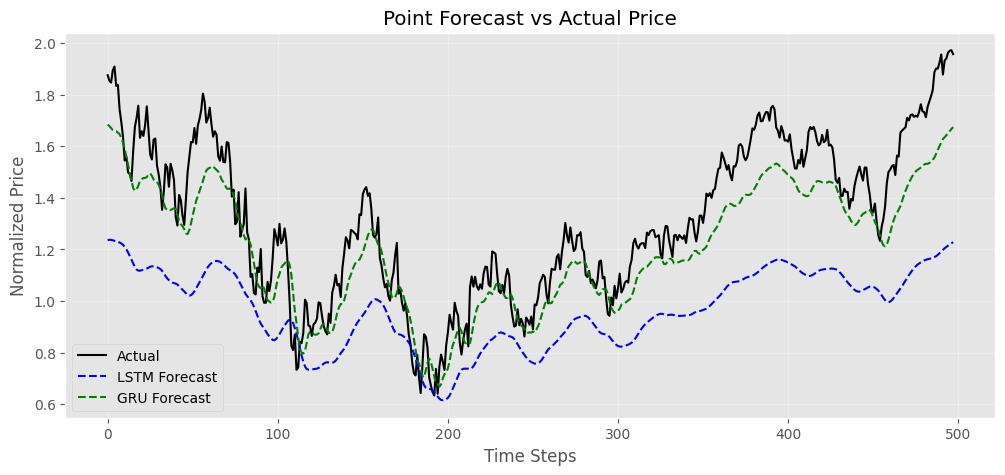

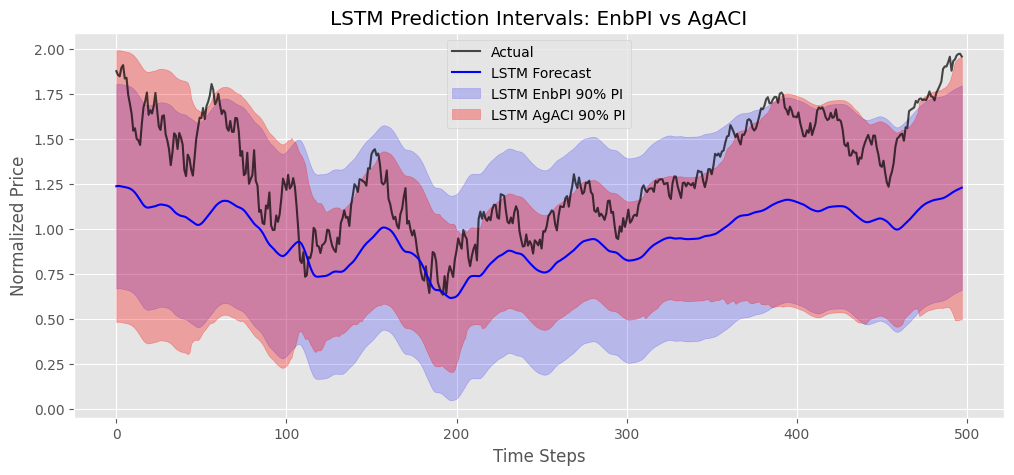


Final Conformal Inference Performance:
Method  Coverage (%)  Avg Width
 EnbPI     86.746988   1.135879
 AgACI     80.321285   0.968180


In [6]:
# Plot 1: Forecast Comparison
plot_forecast_vs_actual(y_test, lstm_test_pred, gru_test_pred)

# Plot 2: Uncertainty Comparison
plot_prediction_intervals(y_test, lstm_test_pred, l_enbpi, u_enbpi, l_agaci, u_agaci, model_name="LSTM")

# Plot 3: Metrics Evaluation
enbpi_cov, enbpi_width = calculate_metrics(y_test, l_enbpi, u_enbpi)
agaci_cov, agaci_width = calculate_metrics(y_test, l_agaci, u_agaci)

# Summary Table
results_df = pd.DataFrame({
    "Method": ["EnbPI", "AgACI"],
    "Coverage (%)": [enbpi_cov * 100, agaci_cov * 100],
    "Avg Width": [enbpi_width, agaci_width]
})

print("\nFinal Conformal Inference Performance:")
print(results_df.to_string(index=False))

# Optional: Save results for later
# results_df.to_csv('../results/final_metrics.csv')